# Sentiment-Based Sorting — Merged Library Domain Notebook

Naive Bayes, Decision Tree, and a Naive Bayes -> Decision Tree hybrid.
Metrics: accuracy, F1-score, recall.

**Dataset:** `merged_library_dataset.csv` — 7,124 rows combining EduRABSA
(6,491 rows, general education reviews) with local six-category student
feedback (633 rows, including library facilities). Already merged and
deduplicated; this notebook loads it directly rather than rebuilding it
from the two original source files.

Columns: `text`, `sentiment` (positive/neutral/negative), `source`
(edurabsa or local), `category` (edurabsa, or one of the six local
categories including library_facilities).

Section 12 evaluates on the library-facilities rows specifically, since
that is the deployment target, not the merged average.


## 1. Setup and load both datasets


In [17]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, recall_score, classification_report, confusion_matrix
import joblib

RANDOM_STATE = 42

df = pd.read_csv('merged_library_dataset.csv')

print('Shape:', df.shape)
print()
print(df['source'].value_counts())
print()
print(df['category'].value_counts())
print()
print(df['sentiment'].value_counts())
df.head()


Shape: (7124, 4)

source
edurabsa    6491
local        633
Name: count, dtype: int64

category
edurabsa              6491
teaching               123
coursecontent          112
examination            102
labwork                100
library_facilities     100
extracurricular         96
Name: count, dtype: int64

sentiment
neutral     3578
positive    2543
negative    1003
Name: count, dtype: int64


,text,sentiment,source,category
0,He is not helpful at all and makes fun of stud...,negative,edurabsa,edurabsa
1,"This course was amazing. For the first time, t...",neutral,edurabsa,edurabsa
2,Exams were very easy and he allowed us to do e...,neutral,edurabsa,edurabsa
3,The lecturers from Exeter have helped me throu...,positive,edurabsa,edurabsa
4,"Extremely boring and lectures were useless, bu...",neutral,edurabsa,edurabsa


## 2. Clean the text


In [18]:
df = df.drop_duplicates(subset='text').reset_index(drop=True)

def preprocess(text):
    text = re.sub(r'[^a-zA-Z\s]', ' ', str(text).lower())
    return ' '.join(text.split())

df['clean'] = df['text'].apply(preprocess)
df = df[df['clean'].str.len() > 0].reset_index(drop=True)
print('Rows after cleaning:', len(df))
print(df['source'].value_counts())


Rows after cleaning: 7122
source
edurabsa    6489
local        633
Name: count, dtype: int64


## 3. Split into train and test

80/20, stratified by sentiment across the merged dataset. Stratifying by
sentiment alone (not by source) means the split may not preserve the exact
EduRABSA-to-local ratio in each class, but it guarantees all three
sentiment classes appear in both sets, which matters more given how small
the local negative and neutral classes are.


In [19]:
train, test = train_test_split(
    df, test_size=0.20, stratify=df['sentiment'], random_state=RANDOM_STATE)

X_train, y_train = train['clean'], train['sentiment']
X_test,  y_test  = test['clean'],  test['sentiment']

vectorizer = CountVectorizer(ngram_range=(1, 2), min_df=2)
Xtr = vectorizer.fit_transform(X_train)
Xte = vectorizer.transform(X_test)

print('Train size:', Xtr.shape[0], '  Test size:', Xte.shape[0])
print('Test class counts:', y_test.value_counts().to_dict())
print('Test rows by source:', test['source'].value_counts().to_dict())
print('Library-facilities rows in test:', (test['category'] == 'library_facilities').sum())


Train size: 5697   Test size: 1425
Test class counts: {'neutral': 716, 'positive': 508, 'negative': 201}
Test rows by source: {'edurabsa': 1309, 'local': 116}
Library-facilities rows in test: 16


## 4. Naive Bayes


In [20]:
nb = MultinomialNB(alpha=0.3)
nb.fit(Xtr, y_train)
nb_pred = nb.predict(Xte)

print('Accuracy :', round(accuracy_score(y_test, nb_pred), 4))
print('F1-score :', round(f1_score(y_test, nb_pred, average='macro'), 4))
print('Recall   :', round(recall_score(y_test, nb_pred, average='macro'), 4))
print()
print(classification_report(y_test, nb_pred, digits=3))


Accuracy : 0.7193
F1-score : 0.6737
Recall   : 0.651

              precision    recall  f1-score   support

    negative      0.710     0.438     0.542       201
     neutral      0.704     0.804     0.751       716
    positive      0.747     0.711     0.729       508

    accuracy                          0.719      1425
   macro avg      0.720     0.651     0.674      1425
weighted avg      0.720     0.719     0.713      1425



## 5. Decision Tree


In [21]:
dt = DecisionTreeClassifier(class_weight='balanced', min_samples_leaf=2, random_state=RANDOM_STATE)
dt.fit(Xtr, y_train)
dt_pred = dt.predict(Xte)

print('Accuracy :', round(accuracy_score(y_test, dt_pred), 4))
print('F1-score :', round(f1_score(y_test, dt_pred, average='macro'), 4))
print('Recall   :', round(recall_score(y_test, dt_pred, average='macro'), 4))
print()
print(classification_report(y_test, dt_pred, digits=3))


Accuracy : 0.6442
F1-score : 0.6054
Recall   : 0.621

              precision    recall  f1-score   support

    negative      0.398     0.532     0.455       201
     neutral      0.731     0.649     0.688       716
    positive      0.665     0.681     0.673       508

    accuracy                          0.644      1425
   macro avg      0.598     0.621     0.605      1425
weighted avg      0.661     0.644     0.650      1425



## 6. Hybrid (Naive Bayes -> Decision Tree)

Naive Bayes classifies every review. Where its confidence is below the
threshold, the Decision Tree decides instead.


In [22]:
class Hybrid(BaseEstimator, ClassifierMixin):
    def __init__(self, threshold=0.9):
        self.threshold = threshold

    def fit(self, X, y):
        self.nb_ = MultinomialNB(alpha=0.3).fit(X, y)
        self.dt_ = DecisionTreeClassifier(class_weight='balanced', min_samples_leaf=2,
                                          random_state=RANDOM_STATE).fit(X, y)
        return self

    def predict(self, X):
        proba = self.nb_.predict_proba(X)
        pred = self.nb_.predict(X).copy()
        low_confidence = proba.max(axis=1) < self.threshold
        if low_confidence.any():
            pred[low_confidence] = self.dt_.predict(X[low_confidence])
        return pred

hybrid = Hybrid(threshold=0.9)
hybrid.fit(Xtr, y_train)
hybrid_pred = hybrid.predict(Xte)

print('Accuracy :', round(accuracy_score(y_test, hybrid_pred), 4))
print('F1-score :', round(f1_score(y_test, hybrid_pred, average='macro'), 4))
print('Recall   :', round(recall_score(y_test, hybrid_pred, average='macro'), 4))
print()
print(classification_report(y_test, hybrid_pred, digits=3))


Accuracy : 0.7375
F1-score : 0.6906
Recall   : 0.6774

              precision    recall  f1-score   support

    negative      0.627     0.478     0.542       201
     neutral      0.742     0.795     0.767       716
    positive      0.764     0.760     0.762       508

    accuracy                          0.738      1425
   macro avg      0.711     0.677     0.691      1425
weighted avg      0.734     0.738     0.734      1425



## 7. Compare all three


In [23]:
results = pd.DataFrame({
    'Model': ['Naive Bayes', 'Decision Tree', 'Hybrid'],
    'Accuracy': [accuracy_score(y_test, nb_pred),
                accuracy_score(y_test, dt_pred),
                accuracy_score(y_test, hybrid_pred)],
    'F1-score': [f1_score(y_test, nb_pred, average='macro'),
                f1_score(y_test, dt_pred, average='macro'),
                f1_score(y_test, hybrid_pred, average='macro')],
    'Recall':   [recall_score(y_test, nb_pred, average='macro'),
                recall_score(y_test, dt_pred, average='macro'),
                recall_score(y_test, hybrid_pred, average='macro')],
}).set_index('Model').round(4)

results


,Accuracy,F1-score,Recall
Model,,,
Naive Bayes,0.7193,0.6737,0.6510
Decision Tree,0.6442,0.6054,0.6210
Hybrid,0.7375,0.6906,0.6774


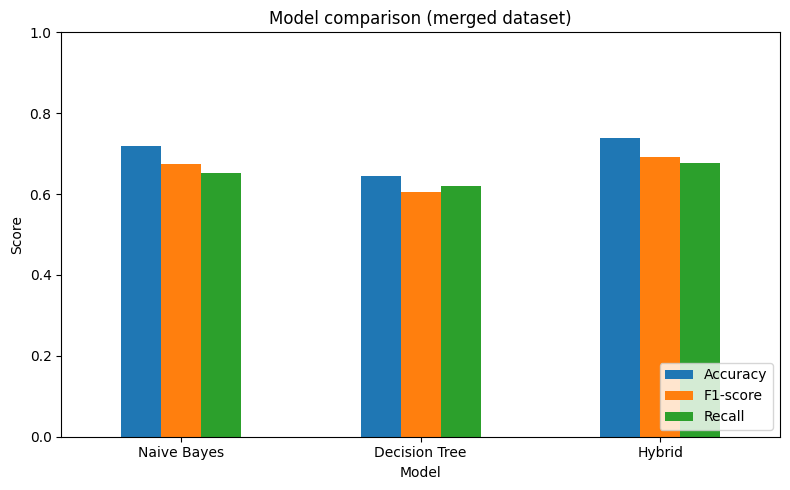

In [24]:
results.plot(kind='bar', figsize=(8, 5), rot=0)
plt.title('Model comparison (merged dataset)')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


## 8. Effect of text preprocessing (Objective 1)


In [25]:
# Same train/test rows, but the vectorizer is fit on the ORIGINAL text
# (before lowercasing, punctuation stripping, etc.) instead of 'clean'.
vectorizer_raw = CountVectorizer(ngram_range=(1, 2), min_df=2)
Xtr_raw = vectorizer_raw.fit_transform(train['text'])
Xte_raw = vectorizer_raw.transform(test['text'])

nb_raw = MultinomialNB(alpha=0.3).fit(Xtr_raw, y_train)
dt_raw = DecisionTreeClassifier(class_weight='balanced', min_samples_leaf=2,
                                random_state=RANDOM_STATE).fit(Xtr_raw, y_train)
hybrid_raw = Hybrid(threshold=0.9).fit(Xtr_raw, y_train)

nb_raw_pred = nb_raw.predict(Xte_raw)
dt_raw_pred = dt_raw.predict(Xte_raw)
hybrid_raw_pred = hybrid_raw.predict(Xte_raw)

preprocessing_effect = pd.DataFrame([
    {'Preprocessing': 'Raw (uncleaned)', 'Model': 'Naive Bayes',
     'Accuracy': accuracy_score(y_test, nb_raw_pred),
     'F1-score': f1_score(y_test, nb_raw_pred, average='macro')},
    {'Preprocessing': 'Raw (uncleaned)', 'Model': 'Decision Tree',
     'Accuracy': accuracy_score(y_test, dt_raw_pred),
     'F1-score': f1_score(y_test, dt_raw_pred, average='macro')},
    {'Preprocessing': 'Raw (uncleaned)', 'Model': 'Hybrid',
     'Accuracy': accuracy_score(y_test, hybrid_raw_pred),
     'F1-score': f1_score(y_test, hybrid_raw_pred, average='macro')},
    {'Preprocessing': 'Cleaned', 'Model': 'Naive Bayes',
     'Accuracy': accuracy_score(y_test, nb_pred),
     'F1-score': f1_score(y_test, nb_pred, average='macro')},
    {'Preprocessing': 'Cleaned', 'Model': 'Decision Tree',
     'Accuracy': accuracy_score(y_test, dt_pred),
     'F1-score': f1_score(y_test, dt_pred, average='macro')},
    {'Preprocessing': 'Cleaned', 'Model': 'Hybrid',
     'Accuracy': accuracy_score(y_test, hybrid_pred),
     'F1-score': f1_score(y_test, hybrid_pred, average='macro')},
]).round(4)

preprocessing_effect


,Preprocessing,Model,Accuracy,F1-score
0,Raw (uncleaned),Naive Bayes,0.7207,0.6742
1,Raw (uncleaned),Decision Tree,0.6386,0.6020
2,Raw (uncleaned),Hybrid,0.7333,0.6845
3,Cleaned,Naive Bayes,0.7193,0.6737
4,Cleaned,Decision Tree,0.6442,0.6054
5,Cleaned,Hybrid,0.7375,0.6906


In [26]:
# The effect, isolated: cleaned minus raw, per model.
delta = preprocessing_effect.pivot(index='Model', columns='Preprocessing', values='Accuracy')
delta['Accuracy change'] = delta['Cleaned'] - delta['Raw (uncleaned)']
print(delta.round(4))
print()
print('Positive = cleaning helped this model. Negative = cleaning hurt it.')
print('Report this table directly for Objective (a) - it measures the effect')
print('instead of only asserting that preprocessing was applied.')


Preprocessing  Cleaned  Raw (uncleaned)  Accuracy change
Model                                                   
Decision Tree   0.6442           0.6386           0.0056
Hybrid          0.7375           0.7333           0.0042
Naive Bayes     0.7193           0.7207          -0.0014

Positive = cleaning helped this model. Negative = cleaning hurt it.
Report this table directly for Objective (a) - it measures the effect
instead of only asserting that preprocessing was applied.


## 9. Save the model for Django

Save the trained hybrid model and the vectorizer **together**, as two
separate `.pkl` files. A common integration bug is saving only the model
and re-fitting the vectorizer at inference time — that builds a different
feature space and produces nonsense predictions. Django's view loads both
with `joblib.load()` and applies them in the same order every time.


In [27]:
joblib.dump(hybrid, 'sentiment_model.pkl')
joblib.dump(vectorizer, 'vectorizer.pkl')
print('Saved: sentiment_model.pkl, vectorizer.pkl')

# Sanity check - this is exactly what your Django view will do:
loaded_model = joblib.load('sentiment_model.pkl')
loaded_vec   = joblib.load('vectorizer.pkl')

for t in ['the aircon on the 2nd floor is too warm', 'the librarian helped me find the book right away']:
    cleaned = preprocess(t)
    pred = loaded_model.predict(loaded_vec.transform([cleaned]))[0]
    print(f'{pred:9} <- {t}')


Saved: sentiment_model.pkl, vectorizer.pkl
neutral   <- the aircon on the 2nd floor is too warm
positive  <- the librarian helped me find the book right away


## 10. Confusion matrices


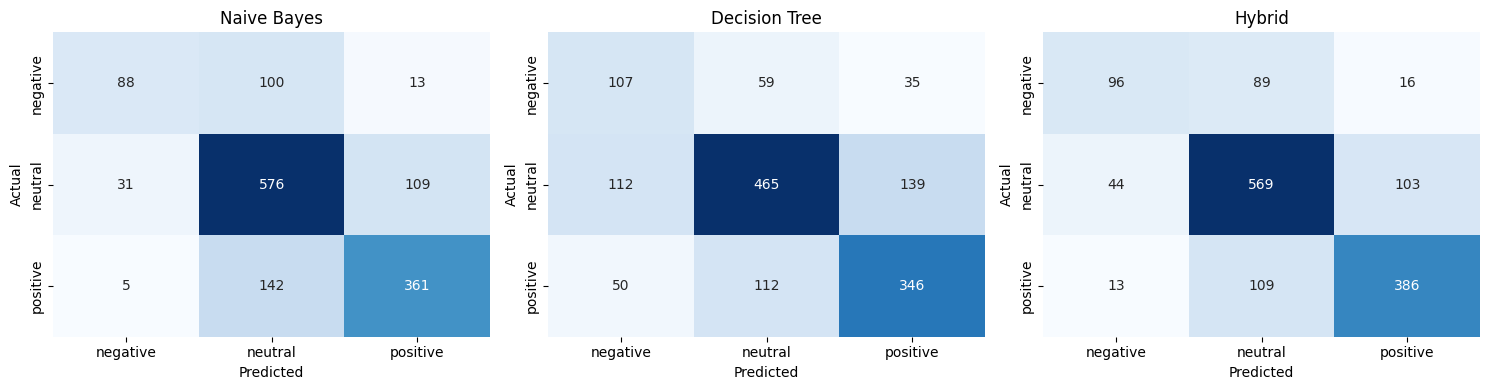

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
labels = ['negative', 'neutral', 'positive']
for ax, name, pred in zip(axes, ['Naive Bayes', 'Decision Tree', 'Hybrid'],
                          [nb_pred, dt_pred, hybrid_pred]):
    cm = confusion_matrix(y_test, pred, labels=labels)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
                xticklabels=labels, yticklabels=labels)
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()


## 11. Cross-validation on the merged training set

A single 80/20 split leaves a modest test set. 5-fold cross-validation on the
training portion gives a mean and standard deviation, so you can say whether
a difference between models is real or just the luck of one split.


In [29]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_rows = []
for name, model in [('Naive Bayes', MultinomialNB(alpha=0.3)),
                    ('Decision Tree', DecisionTreeClassifier(class_weight='balanced', min_samples_leaf=2, random_state=RANDOM_STATE)),
                    ('Hybrid', Hybrid(threshold=0.9))]:
    pipe = Pipeline([('v', CountVectorizer(ngram_range=(1,2), min_df=2)), ('c', model)])
    acc = cross_val_score(pipe, train['clean'], train['sentiment'], cv=cv, scoring='accuracy')
    f1m = cross_val_score(pipe, train['clean'], train['sentiment'], cv=cv, scoring='f1_macro')
    cv_rows.append({'Model': name,
                    'CV Accuracy': f'{acc.mean():.4f} +/- {acc.std():.4f}',
                    'CV Macro F1': f'{f1m.mean():.4f} +/- {f1m.std():.4f}'})
pd.DataFrame(cv_rows).set_index('Model')


,CV Accuracy,CV Macro F1
Model,,
Naive Bayes,0.7258 +/- 0.0042,0.6875 +/- 0.0045
Decision Tree,0.6517 +/- 0.0157,0.6213 +/- 0.0178
Hybrid,0.7442 +/- 0.0096,0.7094 +/- 0.0148


## 12. Sort feedback by sentiment priority

Negative first, then neutral, then positive.


In [30]:
SENTIMENT_PRIORITY = {'negative': 0, 'neutral': 1, 'positive': 2}

def sort_feedback(texts):
    cleaned = [preprocess(t) for t in texts]
    V = vectorizer.transform(cleaned)
    labels_ = hybrid.predict(V)
    out = pd.DataFrame({'feedback': texts, 'sentiment': labels_})
    out['priority'] = out['sentiment'].map(SENTIMENT_PRIORITY)
    return out.sort_values('priority').drop(columns='priority').reset_index(drop=True)

sample = [
    "the wifi keeps dropping on the 2nd floor quiet study area",
    "the librarian at the circulation desk was very helpful",
    "the collection has enough books but the database access is limited",
    "i never got a reply about the reserved book i requested",
    "borrowing and returning was fast and easy, thank you",
]
sort_feedback(sample)


,feedback,sentiment
0,the wifi keeps dropping on the 2nd floor quiet...,neutral
1,the collection has enough books but the databa...,neutral
2,the librarian at the circulation desk was very...,positive
3,i never got a reply about the reserved book i ...,positive
4,"borrowing and returning was fast and easy, tha...",positive


## 13. Library-facilities performance

This is the actual deployment target. It isolates the library-facilities
rows in the test set and reports how each model does on them specifically,
separate from the merged average above.


In [31]:
lib_mask = test['category'] == 'library_facilities'
lib_test = test[lib_mask]
lib_Xte = vectorizer.transform(lib_test['clean'])
lib_ytrue = lib_test['sentiment']

print('Library-facilities rows in test set:', len(lib_test))
print(lib_ytrue.value_counts().to_dict())
print()

for name, model in [('Naive Bayes', nb), ('Decision Tree', dt), ('Hybrid', hybrid)]:
    pred = model.predict(lib_Xte)
    acc = accuracy_score(lib_ytrue, pred)
    f1 = f1_score(lib_ytrue, pred, average='macro', zero_division=0)
    print(f'{name:15} accuracy={acc:.4f}  macro F1={f1:.4f}')

print()
print('--- Hybrid detail on library-facilities rows only ---')
lib_pred = hybrid.predict(lib_Xte)
print(classification_report(lib_ytrue, lib_pred, digits=3, zero_division=0))


Library-facilities rows in test set: 16
{'positive': 9, 'negative': 4, 'neutral': 3}

Naive Bayes     accuracy=0.6250  macro F1=0.5167
Decision Tree   accuracy=0.6875  macro F1=0.5259
Hybrid          accuracy=0.8125  macro F1=0.5825

--- Hybrid detail on library-facilities rows only ---
              precision    recall  f1-score   support

    negative      0.667     1.000     0.800         4
     neutral      0.000     0.000     0.000         3
    positive      0.900     1.000     0.947         9

    accuracy                          0.812        16
   macro avg      0.522     0.667     0.582        16
weighted avg      0.673     0.812     0.733        16

